# Walmart Weekly Sales Forecasting — Gradient Boosting + Per-Series Ensemble

This notebook builds two independent forecasting branches on the Walmart
Recruiting store-sales dataset and combines their validation predictions into
a single blended model:

1. A tree-based branch (XGBoost) wrapped end-to-end in an sklearn `Pipeline`
   that accepts raw `Store/Dept/Date/IsHoliday` rows and performs all
   merging and feature engineering internally.
2. A per-series branch (Prophet) fit independently on every Store/Dept
   combination in the full population, using Prophet's native holiday
   mechanism.

Both branches are evaluated on the **same** held-out validation window, and
their aligned predictions are combined with a simple weighted blend and a
cross-fit stacked meta-model, keeping whichever validates better. The same
combination is then applied to the competition's `test.csv` to produce a
submission file.

Reported metrics: RMSE (primary evaluation target for this notebook) and
WMAE (the competition's official metric — non-holiday weeks weight 1,
holiday weeks weight 5). WMAE is computed only at evaluation time, never
baked into any model fit.

## 1. Setup

In [1]:
!pip install -q xgboost prophet mlflow dagshub joblib pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0

In [2]:
import itertools
import logging
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, ParameterGrid, TimeSeriesSplit
from sklearn.pipeline import Pipeline

import xgboost as xgb
from prophet import Prophet

import mlflow
import mlflow.sklearn
import dagshub
from mlflow.models.signature import infer_signature

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

print(f"xgboost {xgb.__version__} | mlflow {mlflow.__version__}")

xgboost 3.3.0 | mlflow 3.14.0


### Data location

Points at wherever `train.csv`, `test.csv`, `stores.csv`, and `features.csv`
live. Tries a Google Drive mount first (Colab); falls back to a local
`./data` directory so the notebook also runs unmodified outside Colab.

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/walmart'
    DATA_DIR = f'{PROJECT_DIR}/data'
    MODELS_DIR = f'{PROJECT_DIR}/models'
except ModuleNotFoundError:
    PROJECT_DIR = '.'
    DATA_DIR = './data'
    MODELS_DIR = './models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Data directory:   {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Mounted at /content/drive
Data directory:   /content/drive/MyDrive/walmart/data
Models directory: /content/drive/MyDrive/walmart/models


### Experiment tracking

Logs to the same DagsHub-hosted MLflow project used elsewhere in this
project (`zberi23/walmart-forecasting`). `dagshub.init(..., mlflow=True)`
configures the MLflow tracking URI and credentials for that project before
`mlflow.set_experiment` is called.

In [4]:
# DagsHub + MLflow setup
DAGSHUB_USERNAME = "zberi23"
DAGSHUB_REPO = "walmart-forecasting"

dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO, mlflow=True)

EXPERIMENT_NAME = "Walmart_Ensemble_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ea7e24c4-833c-462d-9b2b-230d5a7c7995&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=10593ec9a5a2b771c1edee7b86e7702ca0e881bd9c51522812c62bc17beb3ee0




Accessing as gbera23-dev

Initialized MLflow to track repo "zberi23/walmart-forecasting"

Repository zberi23/walmart-forecasting initialized!

2026/07/23 06:49:56 INFO mlflow.tracking.fluent: Experiment with name 'Walmart_Ensemble_Training' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/zberi23/walmart-forecasting.mlflow
Experiment: Walmart_Ensemble_Training


## 2. Raw data loading

Everything downstream is built from the four raw competition files. The
preprocessing pipeline performs the merges internally, so nothing is
pre-joined here.

In [5]:
def _read_any(base_path):
    """Read a CSV whether it is stored plain or as a .zip."""
    for suffix in ('.zip', ''):
        path = f'{base_path}{suffix}'
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f'Could not find {base_path} or {base_path}.zip')


train_raw = _read_any(f'{DATA_DIR}/train.csv')
test_raw = _read_any(f'{DATA_DIR}/test.csv')
stores_raw = _read_any(f'{DATA_DIR}/stores.csv')
features_raw = _read_any(f'{DATA_DIR}/features.csv')

for frame in (train_raw, test_raw, features_raw):
    frame['Date'] = pd.to_datetime(frame['Date'])

for frame, name in [(train_raw, 'train'), (test_raw, 'test'), (features_raw, 'features')]:
    assert pd.api.types.is_datetime64_any_dtype(frame['Date']), f'{name}.Date failed to parse'

assert train_raw['Store'].dtype == stores_raw['Store'].dtype == features_raw['Store'].dtype, \
    'Store dtype mismatch across files would silently break merges'

print(f"Train:    {train_raw.shape}")
print(f"Test:     {test_raw.shape}")
print(f"Stores:   {stores_raw.shape}")
print(f"Features: {features_raw.shape}")
train_raw.head(3)

Train:    (421570, 5)
Test:     (115064, 4)
Stores:   (45, 3)
Features: (8190, 12)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False


## 3. Exploratory data analysis

In [6]:
eda = train_raw.merge(stores_raw, on='Store', how='left') \
                .merge(features_raw, on=['Store', 'Date', 'IsHoliday'], how='left')

print("Store count:", train_raw['Store'].nunique())
print("Dept count:", train_raw['Dept'].nunique())
print("Store-Dept series:", train_raw.groupby(['Store', 'Dept']).ngroups)
print("Date range:", train_raw['Date'].min(), "->", train_raw['Date'].max())

series_lengths = train_raw.groupby(['Store', 'Dept']).size()
print("\nWeeks of history per series:")
print(series_lengths.describe())

Store count: 45
Dept count: 81
Store-Dept series: 3331
Date range: 2010-02-05 00:00:00 -> 2012-10-26 00:00:00

Weeks of history per series:
count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64


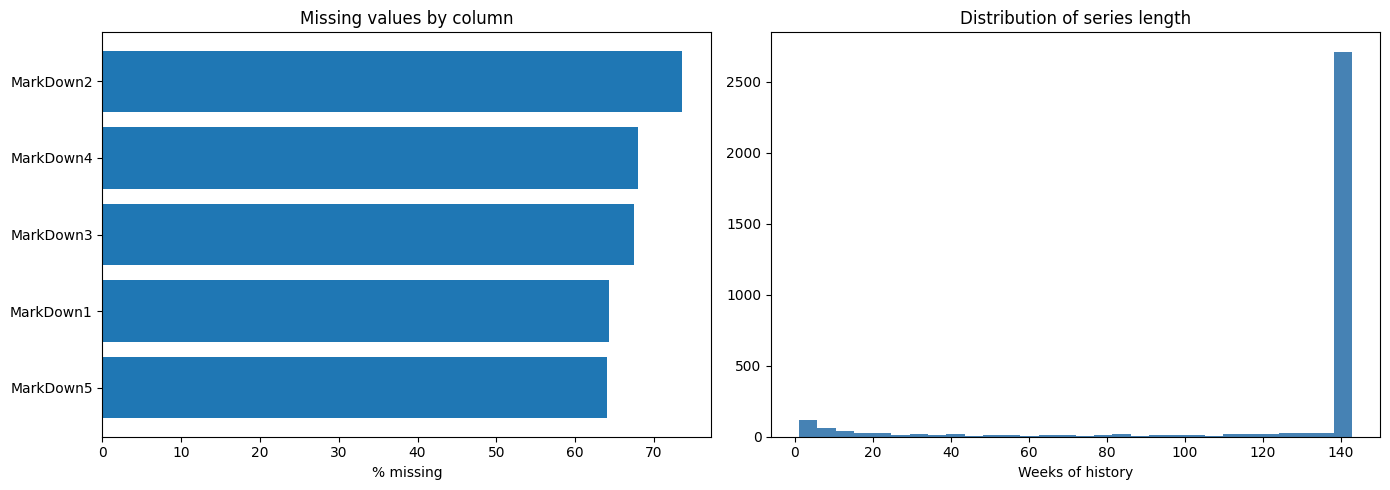

MarkDown2    73.611025
MarkDown4    67.984676
MarkDown3    67.480845
MarkDown1    64.257181
MarkDown5    64.079038
dtype: float64


In [7]:
missing = eda.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(missing.index[::-1], missing.values[::-1])
axes[0].set_xlabel('% missing')
axes[0].set_title('Missing values by column')

axes[1].hist(series_lengths.values, bins=30, color='steelblue')
axes[1].set_xlabel('Weeks of history')
axes[1].set_title('Distribution of series length')
plt.tight_layout()
plt.show()
print(missing)

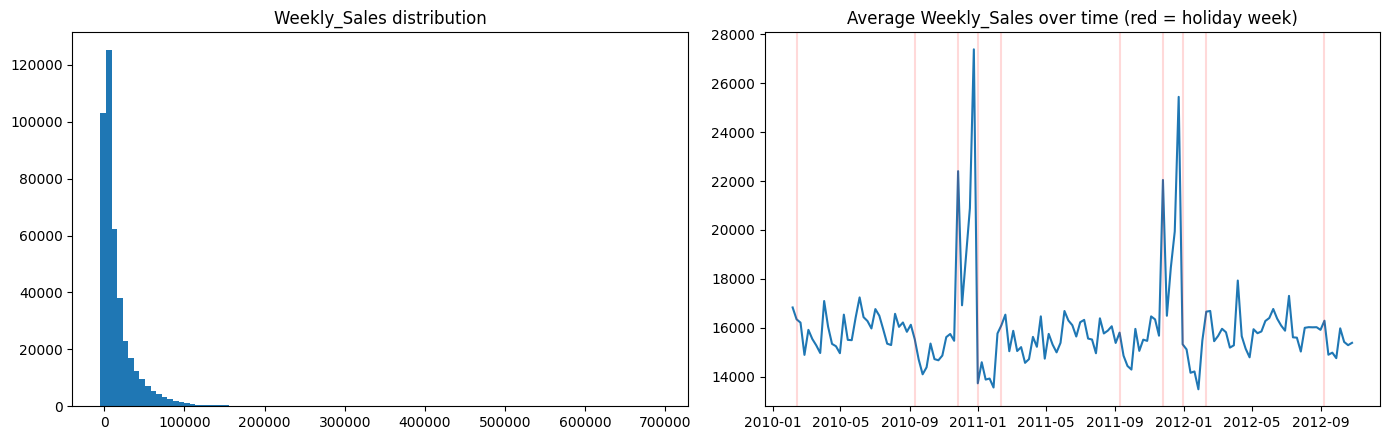

                   mean   median   count
IsHoliday                               
False      15901.445069  7589.95  391909
True       17035.823187  7947.74   29661


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(eda['Weekly_Sales'], bins=100)
axes[0].set_title('Weekly_Sales distribution')

weekly_avg = eda.groupby('Date')['Weekly_Sales'].mean()
axes[1].plot(weekly_avg.index, weekly_avg.values)
for d in eda.loc[eda['IsHoliday'], 'Date'].unique():
    axes[1].axvline(pd.Timestamp(d), color='red', alpha=0.15)
axes[1].set_title('Average Weekly_Sales over time (red = holiday week)')
plt.tight_layout()
plt.show()

print(eda.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'count']))

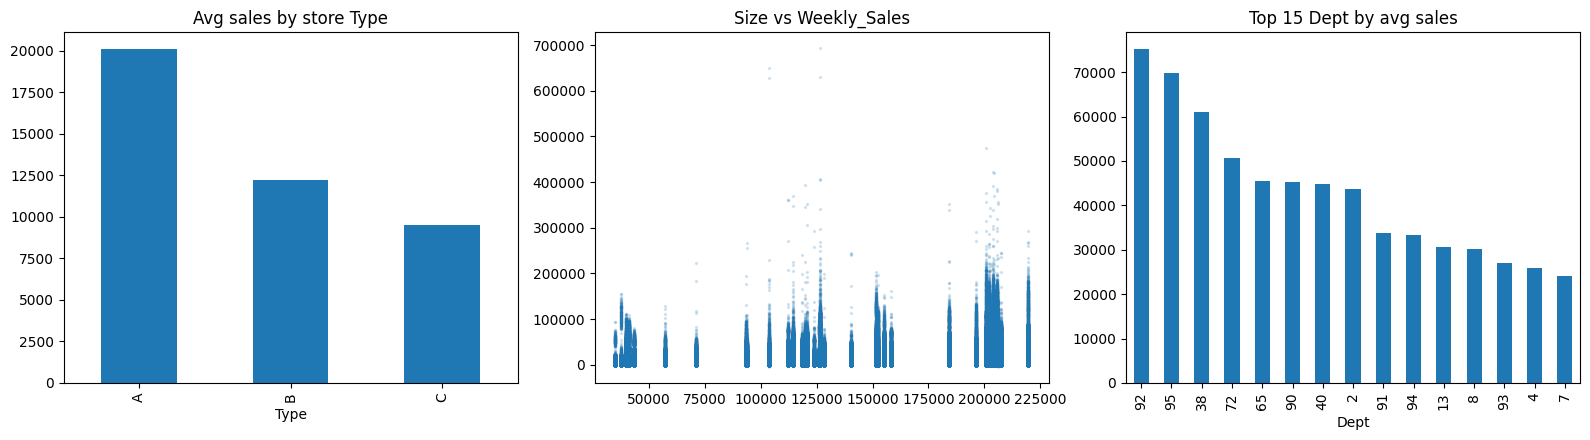

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
eda.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0], title='Avg sales by store Type')
axes[1].scatter(eda['Size'], eda['Weekly_Sales'], s=2, alpha=0.15)
axes[1].set_title('Size vs Weekly_Sales')
eda.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(15) \
   .plot(kind='bar', ax=axes[2], title='Top 15 Dept by avg sales')
plt.tight_layout()
plt.show()

**Takeaways:** `Weekly_Sales` is right-skewed with substantial Store/Dept/Size
variation; holiday weeks run measurably higher on average, which is what the
competition's 5x holiday weighting is meant to capture; MarkDown1-5 are the
most missing-heavy columns since that promotion only started in Nov 2011;
CPI/Unemployment/Temperature/Fuel_Price have sparse per-store gaps. These
observations directly motivate the feature engineering and fill strategy
below.

## 4. Shared validation window

Both branches — and the ensembling step that combines them — must score
against the exact same held-out slice of time, otherwise any observed "lift"
from ensembling would be an artifact of comparing different data. The last
`GLOBAL_VAL_WEEKS` calendar weeks of the labelled training period are held
out as that shared window; everything before it is available for fitting.

In [10]:
GLOBAL_VAL_WEEKS = 12

def compute_val_cutoff(frame, val_weeks=GLOBAL_VAL_WEEKS):
    unique_dates = np.sort(frame['Date'].unique())
    if val_weeks >= len(unique_dates):
        raise ValueError('val_weeks exceeds the number of unique dates in the training data')
    return unique_dates[-val_weeks]


train_sorted = train_raw.sort_values('Date').reset_index(drop=True)
VAL_CUTOFF_DATE = compute_val_cutoff(train_sorted)

train_mask = train_sorted['Date'] < VAL_CUTOFF_DATE
val_mask = ~train_mask

X_train_raw = train_sorted.loc[train_mask].drop(columns=['Weekly_Sales'])
y_train = train_sorted.loc[train_mask, 'Weekly_Sales'].to_numpy()
X_val_raw = train_sorted.loc[val_mask].drop(columns=['Weekly_Sales'])
y_val = train_sorted.loc[val_mask, 'Weekly_Sales'].to_numpy()

assert X_train_raw['Date'].max() < X_val_raw['Date'].min(), 'validation window is not strictly after training window'

print(f"Validation cutoff: {pd.Timestamp(VAL_CUTOFF_DATE).date()}")
print(f"Train: {X_train_raw.shape}, range {X_train_raw['Date'].min().date()} -> {X_train_raw['Date'].max().date()}")
print(f"Val:   {X_val_raw.shape}, range {X_val_raw['Date'].min().date()} -> {X_val_raw['Date'].max().date()}")

Validation cutoff: 2012-08-10
Train: (386007, 4), range 2010-02-05 -> 2012-08-03
Val:   (35563, 4), range 2012-08-10 -> 2012-10-26


## 5. Metrics

RMSE is the primary target metric for this notebook. WMAE (5x weight on
holiday weeks, 1x otherwise) is computed and logged alongside it throughout,
since it's the competition's official scoring metric, but is never used to
influence model fitting itself — only evaluation.

In [11]:
def weighted_mae(y_true, y_pred, is_holiday):
    weights = np.where(np.asarray(is_holiday).astype(bool), 5.0, 1.0)
    return float(np.sum(weights * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(weights))


def root_mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def report_metrics(y_true, y_pred, is_holiday):
    return {
        'rmse': root_mean_squared_error(y_true, y_pred),
        'wmae': weighted_mae(y_true, y_pred, is_holiday),
    }

## 6. Feature pipeline (XGBoost branch)

`SalesFeatureBuilder` is an sklearn `BaseEstimator`/`TransformerMixin` that
takes raw `Store/Dept/Date/IsHoliday` rows and performs every merge and
transformation internally:

- Merges against `features_raw` (Store-week covariates) and `stores_raw`
  (static store metadata) inside `transform`, never before it.
- Fills `MarkDown1-5` with 0 and `CPI`/`Unemployment`/`Temperature`/`Fuel_Price`
  via a per-store forward-fill then back-fill.
- Builds the full calendar feature set (year/month/week/quarter/day-of-year,
  week-of-month, month start/end flags, cyclical month/week encodings,
  explicit Super Bowl / Labor Day / Thanksgiving / Christmas flags, and
  days-to-nearest-holiday).
- Builds markdown-derived, size-bucket, dept-rank, and store-type features.
- Builds Store/Dept lag and rolling-sales features (`lag_1`, `lag_52`,
  `roll_4_mean`, `roll_12_mean`) using `shift(1)` before any rolling window,
  fit only on the slice passed to `fit()`, and attached to any incoming
  frame — train, validation, or the raw competition test set — via
  `pd.merge_asof(direction='backward')` keyed on Store/Dept/Date. This means
  dates beyond the fit window still receive the most recent known value
  instead of `NaN`. Any Store/Dept combination with no history at all falls
  back to the global training mean, not zero.

In [12]:
MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

HOLIDAY_CALENDAR = pd.DataFrame({
    'holiday': ['SuperBowl'] * 4 + ['LaborDay'] * 4 + ['Thanksgiving'] * 4 + ['Christmas'] * 4,
    'ds': pd.to_datetime([
        '2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08',
        '2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06',
        '2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29',
        '2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27',
    ]),
    'lower_window': [-1] * 16,
    'upper_window': [1] * 16,
})


def holiday_dates_for(name):
    return pd.DatetimeIndex(HOLIDAY_CALENDAR.loc[HOLIDAY_CALENDAR['holiday'] == name, 'ds'])

In [13]:
class SalesFeatureBuilder(BaseEstimator, TransformerMixin):
    """Turns raw Store/Dept/Date/IsHoliday rows into a model-ready feature matrix."""

    def __init__(self, store_meta, weekly_features):
        self.store_meta = store_meta
        self.weekly_features = weekly_features

    def fit(self, X, y=None):
        store_meta = self.store_meta.copy()
        weekly_features = self.weekly_features.copy()
        if not pd.api.types.is_datetime64_any_dtype(weekly_features['Date']):
            weekly_features['Date'] = pd.to_datetime(weekly_features['Date'])
        self.store_meta_ = store_meta
        self.weekly_features_ = weekly_features

        X = X.copy()
        if not pd.api.types.is_datetime64_any_dtype(X['Date']):
            X['Date'] = pd.to_datetime(X['Date'])

        dept_counts = X['Dept'].value_counts()
        self.dept_rank_map_ = {d: r for r, d in enumerate(dept_counts.index)}

        if y is None:
            if 'Weekly_Sales' not in X.columns:
                raise ValueError('fit() needs Weekly_Sales in X or an explicit y')
            y_arr = X['Weekly_Sales'].to_numpy(dtype=float)
        else:
            y_arr = np.asarray(y, dtype=float)

        hist = X[['Store', 'Dept', 'Date']].copy()
        hist['Weekly_Sales'] = y_arr
        hist = hist.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

        grp = hist.groupby(['Store', 'Dept'])['Weekly_Sales']
        hist['lag_1'] = grp.shift(1)
        hist['lag_52'] = grp.shift(52)
        hist['roll_4_mean'] = grp.transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
        hist['roll_12_mean'] = grp.transform(lambda s: s.shift(1).rolling(12, min_periods=1).mean())

        global_mean = float(np.nanmean(y_arr))
        self.fallback_values_ = {
            'lag_1': global_mean, 'lag_52': global_mean,
            'roll_4_mean': global_mean, 'roll_12_mean': global_mean,
        }
        self.history_table_ = (
            hist[['Store', 'Dept', 'Date', 'lag_1', 'lag_52', 'roll_4_mean', 'roll_12_mean']]
            .sort_values('Date')
            .reset_index(drop=True)
        )
        return self

    def transform(self, X):
        df = X.copy()
        if not pd.api.types.is_datetime64_any_dtype(df['Date']):
            df['Date'] = pd.to_datetime(df['Date'])

        df = df.merge(self.weekly_features_, on=['Store', 'Date', 'IsHoliday'], how='left')
        df = df.merge(self.store_meta_, on='Store', how='left')

        present_markdowns = [c for c in MARKDOWN_COLS if c in df.columns]
        for c in present_markdowns:
            df[c] = df[c].fillna(0.0)

        for c in ['CPI', 'Unemployment', 'Temperature', 'Fuel_Price']:
            if c in df.columns:
                df[c] = df.groupby('Store')[c].transform(lambda s: s.ffill().bfill())

        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
        df['Day_of_Year'] = df['Date'].dt.dayofyear
        df['Quarter'] = df['Date'].dt.quarter
        df['WeekOfMonth'] = ((df['Date'].dt.day - 1) // 7 + 1).astype(int)
        df['Is_MonthStart'] = df['Date'].dt.is_month_start.astype(int)
        df['Is_MonthEnd'] = df['Date'].dt.is_month_end.astype(int)

        for name in ['SuperBowl', 'LaborDay', 'Thanksgiving', 'Christmas']:
            df[f'Is_{name}'] = df['Date'].isin(holiday_dates_for(name)).astype(int)

        # Vectorized nearest-holiday distance via searchsorted -- avoids any
        # row-wise .apply() and avoids deprecated Index.append() chains for
        # building the combined holiday date array.
        all_holiday_dates = np.array(
            sorted(pd.DatetimeIndex(HOLIDAY_CALENDAR['ds']).unique())
        ).astype('datetime64[D]')
        date_arr = df['Date'].to_numpy().astype('datetime64[D]')
        right_idx = np.clip(np.searchsorted(all_holiday_dates, date_arr, side='left'), 0, len(all_holiday_dates) - 1)
        left_idx = np.clip(right_idx - 1, 0, len(all_holiday_dates) - 1)
        dist_right = np.abs((all_holiday_dates[right_idx] - date_arr).astype('timedelta64[D]').astype(int))
        dist_left = np.abs((all_holiday_dates[left_idx] - date_arr).astype('timedelta64[D]').astype(int))
        df['Days_To_Holiday'] = np.minimum(dist_left, dist_right)

        df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
        df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
        df['Week_Sin'] = np.sin(2 * np.pi * df['Week'] / 52)
        df['Week_Cos'] = np.cos(2 * np.pi * df['Week'] / 52)

        if present_markdowns:
            df['MarkDown_Total'] = df[present_markdowns].sum(axis=1)
            df['MarkDown_Active_Count'] = (df[present_markdowns] > 0).sum(axis=1)
        else:
            df['MarkDown_Total'] = 0.0
            df['MarkDown_Active_Count'] = 0

        df['Size_Per_Dept_Rank'] = df['Dept'].map(self.dept_rank_map_).fillna(-1).astype(float)
        size_bins = [0, 50000, 100000, 150000, 200000, np.inf]
        df['Size_Bucket'] = pd.cut(df['Size'], bins=size_bins, labels=False)

        type_map = {'A': 0, 'B': 1, 'C': 2}
        df['Type_Encoded'] = df['Type'].map(type_map)
        df['IsHoliday'] = df['IsHoliday'].astype(int)

        lag_cols = ['lag_1', 'lag_52', 'roll_4_mean', 'roll_12_mean']
        left = df[['Store', 'Dept', 'Date']].sort_values('Date')
        merged_hist = pd.merge_asof(
            left, self.history_table_, on='Date', by=['Store', 'Dept'], direction='backward'
        ).set_index(left.index).sort_index()
        for c in lag_cols:
            df[c] = merged_hist[c].fillna(self.fallback_values_[c])

        df = df.drop(columns=['Date', 'Type'])
        return df


class ColumnSubsetSelector(BaseEstimator, TransformerMixin):
    """Pipeline-compatible feature-subset selector."""
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns]

In [14]:
# Sanity pass: fit on the pre-cutoff slice, transform train/val/the raw competition test set.
feature_builder = SalesFeatureBuilder(stores_raw, features_raw)
feature_builder.fit(X_train_raw, y_train)

X_train_feat = feature_builder.transform(X_train_raw)
X_val_feat = feature_builder.transform(X_val_raw)
X_test_feat = feature_builder.transform(test_raw)

for name, frame in [('train', X_train_feat), ('val', X_val_feat), ('test', X_test_feat)]:
    n_nans = int(frame.isnull().sum().sum())
    print(f"{name:5s} shape={frame.shape}  NaNs after transform={n_nans}")
    assert n_nans == 0, f'unexpected NaNs remain in {name} after preprocessing'

assert 'Date' not in X_train_feat.columns and 'Type' not in X_train_feat.columns
print(f"\nFeature columns ({X_train_feat.shape[1]}): {list(X_train_feat.columns)}")

train shape=(386007, 39)  NaNs after transform=0
val   shape=(35563, 39)  NaNs after transform=0
test  shape=(115064, 39)  NaNs after transform=0

Feature columns (39): ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Day_of_Year', 'Quarter', 'WeekOfMonth', 'Is_MonthStart', 'Is_MonthEnd', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'Days_To_Holiday', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'MarkDown_Total', 'MarkDown_Active_Count', 'Size_Per_Dept_Rank', 'Size_Bucket', 'Type_Encoded', 'lag_1', 'lag_52', 'roll_4_mean', 'roll_12_mean']


## 7. Run — Feature selection

Compares four feature-set variants on a baseline XGBoost model and keeps
whichever gives the lowest validation WMAE.

In [15]:
def build_feature_sets(all_columns):
    all_columns = list(all_columns)
    core = ['Store', 'Dept', 'IsHoliday', 'Size', 'Type_Encoded',
            'Year', 'Month', 'Week', 'Day_of_Year',
            'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas',
            'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos']
    extended = core + ['Quarter', 'WeekOfMonth', 'Is_MonthStart', 'Is_MonthEnd',
                        'Days_To_Holiday', 'MarkDown_Total', 'MarkDown_Active_Count',
                        'Size_Bucket', 'Size_Per_Dept_Rank',
                        'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                        'lag_1', 'lag_52', 'roll_4_mean', 'roll_12_mean']
    return {
        'all': all_columns,
        'no_markdown': [c for c in all_columns if c not in MARKDOWN_COLS],
        'core': [c for c in core if c in all_columns],
        'extended': [c for c in extended if c in all_columns],
    }


FEATURE_SETS = build_feature_sets(X_train_feat.columns)
BASELINE_PARAMS = dict(n_estimators=200, max_depth=8, learning_rate=0.1,
                        random_state=42, tree_method='hist', n_jobs=-1)

feature_selection_scores = {}

with mlflow.start_run(run_name="XGBoost_Feature_Selection"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("feature_sets_tested", list(FEATURE_SETS.keys()))

    for fs_name, cols in FEATURE_SETS.items():
        with mlflow.start_run(run_name=f"FS_{fs_name}", nested=True):
            model = xgb.XGBRegressor(**BASELINE_PARAMS)
            model.fit(X_train_feat[cols], y_train)
            preds = model.predict(X_val_feat[cols])
            metrics = report_metrics(y_val, preds, X_val_feat['IsHoliday'])
            feature_selection_scores[fs_name] = metrics

            mlflow.log_param("feature_set", fs_name)
            mlflow.log_param("n_features", len(cols))
            mlflow.log_metrics(metrics)
            print(f"[{fs_name:12s}] n_features={len(cols):3d}  rmse={metrics['rmse']:9.2f}  wmae={metrics['wmae']:9.2f}")

    BEST_FEATURE_SET_NAME = min(feature_selection_scores, key=lambda k: feature_selection_scores[k]['wmae'])
    mlflow.log_param("best_feature_set", BEST_FEATURE_SET_NAME)
    mlflow.log_metrics({f"best_{k}": v for k, v in feature_selection_scores[BEST_FEATURE_SET_NAME].items()})
    mlflow.set_tag("stage", "feature_selection")

BEST_FEATURES = FEATURE_SETS[BEST_FEATURE_SET_NAME]
print(f"\nBest feature set: {BEST_FEATURE_SET_NAME} ({len(BEST_FEATURES)} features)")

[all         ] n_features= 39  rmse=  4515.83  wmae=  2066.70
🏃 View run FS_all at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/96ed621bf7d543b0964c15d13f997aff
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
[no_markdown ] n_features= 34  rmse=  4520.34  wmae=  2063.04
🏃 View run FS_no_markdown at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/3f6b91dd12af44728a0783fb688e4047
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
[core        ] n_features= 17  rmse=  3822.78  wmae=  2281.81
🏃 View run FS_core at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/5b6e32fc86764415924ad44d3c1149b1
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
[extended    ] n_features= 34  rmse=  4515.07  wmae=  2061.76
🏃 View run FS_extended at: https://dagshub.com/zberi23/walmart-forecast

## 8. Run — Cross-validation

`TimeSeriesSplit` respects chronological order (no shuffling). Critically,
`SalesFeatureBuilder` is refit from scratch **inside every fold**, on that
fold's own training slice only — never fit once globally and reused — so lag
and rolling features can never see rows from a later fold.

In [16]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_scores = []

with mlflow.start_run(run_name="XGBoost_CrossValidation"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("cv_method", "TimeSeriesSplit")
    mlflow.log_param("n_splits", N_SPLITS)
    mlflow.log_param("feature_set", BEST_FEATURE_SET_NAME)

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_raw)):
        X_tr_fold_raw = X_train_raw.iloc[tr_idx]
        y_tr_fold = y_train[tr_idx]
        X_va_fold_raw = X_train_raw.iloc[va_idx]
        y_va_fold = y_train[va_idx]

        fold_builder = SalesFeatureBuilder(stores_raw, features_raw)
        fold_builder.fit(X_tr_fold_raw, y_tr_fold)
        assert fold_builder.history_table_['Date'].max() <= X_tr_fold_raw['Date'].max(), \
            'fold preprocessor history leaked past this fold training window'

        X_tr_fold = fold_builder.transform(X_tr_fold_raw)[BEST_FEATURES]
        X_va_fold = fold_builder.transform(X_va_fold_raw)[BEST_FEATURES]

        model = xgb.XGBRegressor(**BASELINE_PARAMS)
        model.fit(X_tr_fold, y_tr_fold)
        preds = model.predict(X_va_fold)
        metrics = report_metrics(y_va_fold, preds, X_va_fold_raw['IsHoliday'].astype(int))
        cv_scores.append(metrics)
        mlflow.log_metric("fold_rmse", metrics['rmse'], step=fold)
        mlflow.log_metric("fold_wmae", metrics['wmae'], step=fold)
        print(f"Fold {fold + 1}: rmse={metrics['rmse']:.2f}  wmae={metrics['wmae']:.2f}")

    cv_rmse = [m['rmse'] for m in cv_scores]
    cv_wmae = [m['wmae'] for m in cv_scores]
    mlflow.log_metric("cv_rmse_mean", float(np.mean(cv_rmse)))
    mlflow.log_metric("cv_rmse_std", float(np.std(cv_rmse)))
    mlflow.log_metric("cv_wmae_mean", float(np.mean(cv_wmae)))
    mlflow.log_metric("cv_wmae_std", float(np.std(cv_wmae)))
    mlflow.set_tag("stage", "cross_validation")

    print(f"\nCV RMSE: {np.mean(cv_rmse):.2f} +/- {np.std(cv_rmse):.2f}")
    print(f"CV WMAE: {np.mean(cv_wmae):.2f} +/- {np.std(cv_wmae):.2f}")

Fold 1: rmse=9401.81  wmae=3978.66
Fold 2: rmse=11720.01  wmae=4795.13
Fold 3: rmse=5239.55  wmae=2571.45
Fold 4: rmse=8434.10  wmae=3508.98
Fold 5: rmse=5960.94  wmae=2729.00

CV RMSE: 8151.28 +/- 2351.82
CV WMAE: 3516.65 +/- 819.98
🏃 View run XGBoost_CrossValidation at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/a4764495098c4acfbca61dfc091abc7e
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4


## 9. Run — Hyperparameter search

Searches over tree depth, learning rate, number of estimators, subsampling,
column sampling, minimum child weight, and L1/L2 regularization. Every
combination is logged as its own nested MLflow run.

In [17]:
# Instead of a random search over the full grid (slow -- each combo refits on the
# entire pre-cutoff training slice), we trial a small, hand-picked set of tiers
# spanning shallow/fast to deep/regularized, so the search finishes quickly while
# still covering the meaningful trade-off (depth/learning_rate/regularization).
FIXED_PARAMS = {'random_state': 42, 'tree_method': 'hist', 'n_jobs': -1}

HYPERPARAM_TIERS = [
    dict(max_depth=4, learning_rate=0.1,  n_estimators=200, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.0, reg_lambda=1.0),
    dict(max_depth=6, learning_rate=0.1,  n_estimators=300, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0),
    dict(max_depth=6, learning_rate=0.05, n_estimators=400, subsample=0.9, colsample_bytree=0.7, min_child_weight=1, reg_alpha=0.0, reg_lambda=1.0),
    dict(max_depth=8, learning_rate=0.1,  n_estimators=300, subsample=0.7, colsample_bytree=0.9, min_child_weight=5, reg_alpha=0.1, reg_lambda=2.0),
    dict(max_depth=8, learning_rate=0.03, n_estimators=400, subsample=0.9, colsample_bytree=0.9, min_child_weight=5, reg_alpha=0.1, reg_lambda=2.0),
]
search_space = HYPERPARAM_TIERS
print(f"Hyperparameter tiers to trial: {len(search_space)}")

grid_results = []
with mlflow.start_run(run_name="XGBoost_HyperparameterSearch"):
    mlflow.log_param("tiers", HYPERPARAM_TIERS)
    mlflow.log_param("fixed_params", FIXED_PARAMS)
    mlflow.log_param("n_iterations", len(search_space))
    mlflow.log_param("feature_set", BEST_FEATURE_SET_NAME)

    for i, combo in enumerate(search_space):
        params = {**FIXED_PARAMS, **combo}
        with mlflow.start_run(run_name=f"Search_{i}", nested=True):
            model = xgb.XGBRegressor(**params)
            model.fit(X_train_feat[BEST_FEATURES], y_train)
            preds = model.predict(X_val_feat[BEST_FEATURES])
            metrics = report_metrics(y_val, preds, X_val_feat['IsHoliday'])

            grid_results.append({**combo, **metrics})
            mlflow.log_params(params)
            mlflow.log_metrics(metrics)

    best_combo = min(grid_results, key=lambda r: r['rmse'])
    BEST_PARAMS = {**FIXED_PARAMS, **{k: v for k, v in best_combo.items() if k not in ('rmse', 'wmae')}}

    mlflow.log_metric("best_val_rmse", best_combo['rmse'])
    mlflow.log_metric("best_val_wmae", best_combo['wmae'])
    mlflow.log_params(BEST_PARAMS)
    mlflow.set_tag("stage", "hyperparameter_search")

print(f"\nBest params: {BEST_PARAMS}")
print(f"Best val RMSE: {best_combo['rmse']:.2f}  |  WMAE: {best_combo['wmae']:.2f}")

Hyperparameter tiers to trial: 5
🏃 View run Search_0 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/f0f812040db84f978d75373b0f8491b5
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
🏃 View run Search_1 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/f3d735d468824fe897a32b287ef21c07
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
🏃 View run Search_2 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/bf7ec99a8d214e8ebeaaaee527e7592b
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
🏃 View run Search_3 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/7502aa2976a94935b81ed3424e59fcab
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
🏃 View run Search_4 at: https://dagshub.com/zberi23/walmart-for

## 10. Run — Final XGBoost pipeline

Wraps preprocessing, feature selection, and the tuned model into a single
`sklearn.Pipeline` that accepts raw `Store/Dept/Date/IsHoliday` rows —
including the competition's raw `test.csv` — directly. Hold-out validation
uses a pipeline fit only on the pre-cutoff slice; a separate production
pipeline is then refit on all labelled data (train + validation) for
generating test-set predictions, with its own metric so it never gets
confused with the honest hold-out score.

In [18]:
xgb_eval_pipeline = Pipeline([
    ('preprocess', SalesFeatureBuilder(stores_raw, features_raw)),
    ('select', ColumnSubsetSelector(BEST_FEATURES)),
    ('model', xgb.XGBRegressor(**BEST_PARAMS)),
])

X_full_raw = train_sorted.drop(columns=['Weekly_Sales'])
y_full = train_sorted['Weekly_Sales'].to_numpy()

with mlflow.start_run(run_name="XGBoost_Final") as xgb_final_run:
    xgb_eval_pipeline.fit(X_train_raw, y_train)
    xgb_val_preds = xgb_eval_pipeline.predict(X_val_raw)
    xgb_val_metrics = report_metrics(y_val, xgb_val_preds, X_val_raw['IsHoliday'].astype(int))

    xgb_production_pipeline = Pipeline([
        ('preprocess', SalesFeatureBuilder(stores_raw, features_raw)),
        ('select', ColumnSubsetSelector(BEST_FEATURES)),
        ('model', xgb.XGBRegressor(**BEST_PARAMS)),
    ])
    xgb_production_pipeline.fit(X_full_raw, y_full)
    full_fit_preds = xgb_production_pipeline.predict(X_full_raw)
    full_fit_metrics = report_metrics(
        y_full, full_fit_preds,
        xgb_production_pipeline.named_steps['preprocess'].transform(X_full_raw)['IsHoliday']
    )

    mlflow.log_params(BEST_PARAMS)
    mlflow.log_param("feature_set", BEST_FEATURE_SET_NAME)
    mlflow.log_param("n_features_used", len(BEST_FEATURES))
    mlflow.log_param("training_rows", len(X_full_raw))
    mlflow.log_metrics({f"val_{k}": v for k, v in xgb_val_metrics.items()})
    mlflow.log_metrics({f"full_data_train_{k}": v for k, v in full_fit_metrics.items()})

    signature = infer_signature(X_val_raw.head(100), xgb_val_preds[:100])
    mlflow.sklearn.log_model(
        sk_model=xgb_production_pipeline,
        artifact_path="xgboost_pipeline",
        signature=signature,
        input_example=X_val_raw.head(5),
        registered_model_name="walmart_xgboost",
        serialization_format="cloudpickle",
    )
    mlflow.set_tag("stage", "final")
    mlflow.set_tag("model_type", "XGBoost")

print(f"Hold-out val   RMSE={xgb_val_metrics['rmse']:.2f}  WMAE={xgb_val_metrics['wmae']:.2f}")
print(f"Full-data fit  RMSE={full_fit_metrics['rmse']:.2f}  WMAE={full_fit_metrics['wmae']:.2f}")

xgb_test_preds = xgb_production_pipeline.predict(test_raw)
assert len(xgb_test_preds) == len(test_raw)
print(f"\nGenerated {len(xgb_test_preds)} XGBoost test-set predictions")

2026/07/23 06:55:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/23 06:55:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'walmart_xgboost' already exists. Creating a new version of this model...
2026/07/23 06:55:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: walmart_xgboost, version 6
Created version '6' of model 'walmart_xgboost'.


🏃 View run XGBoost_Final at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/785bab227d6b42fab09dd5a00c899649
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
Hold-out val   RMSE=4518.31  WMAE=2051.13
Full-data fit  RMSE=2199.66  WMAE=1185.79

Generated 115064 XGBoost test-set predictions


In [19]:
# XGBoost validation predictions, aligned to Store/Dept/Date, ready to feed into ensembling.
xgb_val_aligned = X_val_raw[['Store', 'Dept', 'Date']].copy()
xgb_val_aligned['y_true'] = y_val
xgb_val_aligned['xgb_pred'] = xgb_val_preds
xgb_val_aligned.head()

,Store,Dept,Date,y_true,xgb_pred
386007,14,24,2012-08-10,6394.95,5567.814941
386008,34,94,2012-08-10,38935.96,39503.136719
386009,4,74,2012-08-10,22466.19,21758.402344
386010,7,42,2012-08-10,7447.46,7621.103027
386011,9,81,2012-08-10,2495.74,2413.106445


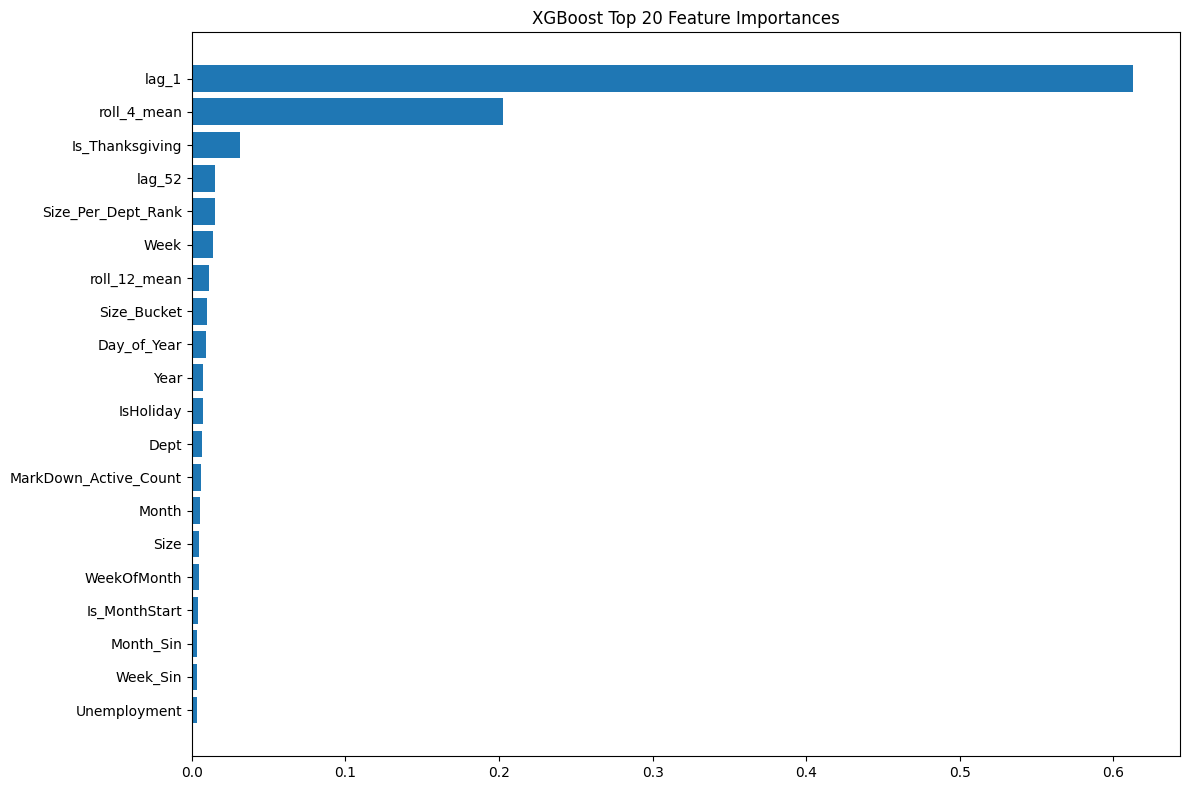

,feature,importance
30,lag_1,0.612797
32,roll_4_mean,0.202495
11,Is_Thanksgiving,0.031247
31,lag_52,0.014999
25,Size_Per_Dept_Rank,0.014799
7,Week,0.013875
33,roll_12_mean,0.010880
24,Size_Bucket,0.010166
8,Day_of_Year,0.009121
5,Year,0.007267


In [20]:
xgb_model = xgb_production_pipeline.named_steps['model']
importances = pd.DataFrame({
    'feature': BEST_FEATURES,
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importances['feature'].head(20)[::-1], importances['importance'].head(20)[::-1])
plt.title('XGBoost Top 20 Feature Importances')
plt.tight_layout()
plt.show()
importances.head(10)

## 11. Prophet branch — holidays and shared validation split

Every Store/Dept series is split at the exact same `VAL_CUTOFF_DATE` used by
the XGBoost branch, so both branches' validation predictions land on
identical dates and can be aligned row-for-row later. Walmart's four known
competition holidays are passed to Prophet's native `holidays=` mechanism
rather than encoded as manual dummy columns.

In [21]:
series_train = {}
series_val = {}
for (store, dept), g in train_sorted.groupby(['Store', 'Dept'], sort=False):
    g = g.sort_values('Date')
    tr = g.loc[g['Date'] < VAL_CUTOFF_DATE]
    va = g.loc[g['Date'] >= VAL_CUTOFF_DATE]
    if len(va) == 0:
        continue
    series_train[(store, dept)] = tr.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})[['ds', 'y']].reset_index(drop=True)
    series_val[(store, dept)] = va.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})[['ds', 'y', 'IsHoliday']].reset_index(drop=True)

print(f"Series with a validation window: {len(series_val)}")
first_key = next(iter(series_train))
overlap = set(series_train[first_key]['ds']) & set(series_val[first_key]['ds'])
print("Train/val date overlap for first series (must be empty):", overlap)
assert len(overlap) == 0

Series with a validation window: 3093
Train/val date overlap for first series (must be empty): set()


In [22]:
def seasonal_naive_forecast(key, horizon):
    """Fallback for series that don't clear the min_history bar: last year's value, or last observed."""
    hist = series_train[key]['y'].to_numpy() if key in series_train else np.array([])
    if len(hist) >= 52:
        return np.full(horizon, hist[-52])
    if len(hist) > 0:
        return np.full(horizon, hist[-1])
    return np.full(horizon, float(np.median(y_train)))


def fit_one_series(key, frame, future_ds, cfg):
    logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
    logging.getLogger('prophet').setLevel(logging.WARNING)
    model = Prophet(
        holidays=HOLIDAY_CALENDAR,
        yearly_seasonality=cfg['yearly_order'],
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode=cfg['seasonality_mode'],
        changepoint_prior_scale=cfg['changepoint_prior_scale'],
        holidays_prior_scale=cfg['holidays_prior_scale'],
    )
    model.fit(frame)
    forecast = model.predict(pd.DataFrame({'ds': future_ds}))
    return {'key': key, 'val_pred': forecast['yhat'].to_numpy()}


def run_prophet_trial(cfg, keys, n_jobs=-1):
    """Fits every eligible series in `keys` independently and scores against series_val.
    The 5x holiday weight is applied only here, at evaluation time -- fit() above
    never sees sample weights or the holiday flag.
    """
    fit_keys = [k for k in keys if k in series_train and len(series_train[k]) >= cfg['min_history']]
    fallback_keys = [k for k in keys if k not in fit_keys]

    t0 = time.time()
    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_one_series)(k, series_train[k], series_val[k]['ds'].to_numpy(), cfg)
        for k in fit_keys
    )
    elapsed = time.time() - t0

    pred_map = {r['key']: r['val_pred'] for r in results}
    y_true_all, y_pred_all, is_hol_all = [], [], []
    for k in keys:
        va = series_val[k]
        y_true_all.append(va['y'].to_numpy())
        y_pred_all.append(pred_map[k] if k in pred_map else seasonal_naive_forecast(k, len(va)))
        is_hol_all.append(va['IsHoliday'].to_numpy())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    is_hol_all = np.concatenate(is_hol_all)

    metrics = report_metrics(y_true_all, y_pred_all, is_hol_all)
    metrics.update({'n_fit': len(fit_keys), 'n_fallback': len(fallback_keys), 'elapsed_sec': elapsed})
    return metrics, pred_map, fallback_keys

## 12. Run — Prophet hyperparameter search

Fitting Prophet is a per-series operation, so trialling 20+ configurations
across the full multi-thousand-series population would not finish in a
reasonable time. Instead, every configuration is trialled on the same fixed,
reproducible random sample of series; the winning configuration is then
fit once across the full population in the next section. `min_history` is
included as a tuned parameter, not a fixed constant — it controls the
train/fallback decision boundary per series and is estimated purely from
each series' training-window row count.

In [23]:
SAMPLE_SIZE = 250
MIN_SAMPLE_HISTORY = 60
eligible_keys = [k for k, v in series_train.items() if len(v) >= MIN_SAMPLE_HISTORY]

sample_rng = np.random.default_rng(0)
sample_idx = sample_rng.permutation(len(eligible_keys))[:min(SAMPLE_SIZE, len(eligible_keys))]
SEARCH_SAMPLE = [eligible_keys[i] for i in sample_idx]
print(f"Tuning on a fixed sample of {len(SEARCH_SAMPLE)} series")

Tuning on a fixed sample of 250 series


In [24]:
BASE_CFG = dict(seasonality_mode='additive', changepoint_prior_scale=0.05,
                 holidays_prior_scale=10.0, yearly_order=10, min_history=100)

grid = list(itertools.product(
    ['additive', 'multiplicative'],   # seasonality_mode
    [0.01, 0.05, 0.1, 0.5],           # changepoint_prior_scale
    [1.0, 10.0, 20.0],                # holidays_prior_scale
    [6, 10, 20],                      # yearly seasonality Fourier order
    [60, 100, 140],                   # min_history
))
base_tuple = (BASE_CFG['seasonality_mode'], BASE_CFG['changepoint_prior_scale'],
              BASE_CFG['holidays_prior_scale'], BASE_CFG['yearly_order'], BASE_CFG['min_history'])

grid_rng = random.Random(42)
grid_rng.shuffle(grid)
sampled = [g for g in grid if g != base_tuple][:23]

SEARCH_CONFIGS = [BASE_CFG] + [
    dict(seasonality_mode=m, changepoint_prior_scale=cps, holidays_prior_scale=hps,
         yearly_order=yo, min_history=mh)
    for (m, cps, hps, yo, mh) in sampled
]
print(f"Total configurations to trial: {len(SEARCH_CONFIGS)}")

Total configurations to trial: 24


In [25]:
prophet_search_log = []
with mlflow.start_run(run_name="Prophet_HyperparameterSearch"):
    mlflow.log_param("sample_size", len(SEARCH_SAMPLE))
    mlflow.log_param("n_configurations", len(SEARCH_CONFIGS))

    for i, cfg in enumerate(SEARCH_CONFIGS):
        metrics, _, _ = run_prophet_trial(cfg, SEARCH_SAMPLE, n_jobs=-1)
        row = {**cfg, **metrics, 'trial': i}
        prophet_search_log.append(row)

        with mlflow.start_run(run_name=f"Prophet_Search_{i:02d}", nested=True):
            mlflow.log_params(cfg)
            mlflow.log_metrics(metrics)

        print(f"[{i:2d}] mode={cfg['seasonality_mode']:<14} cps={cfg['changepoint_prior_scale']:<5} "
              f"hps={cfg['holidays_prior_scale']:<5} yo={cfg['yearly_order']:<3} min_hist={cfg['min_history']:<4} "
              f"-> rmse={metrics['rmse']:.2f}  wmae={metrics['wmae']:.2f}")

    prophet_search_df = pd.DataFrame(prophet_search_log)
    best_row = prophet_search_df.sort_values('rmse').iloc[0]
    mlflow.log_metric("best_sample_rmse", best_row['rmse'])
    mlflow.log_metric("best_sample_wmae", best_row['wmae'])
    mlflow.set_tag("stage", "hyperparameter_search")

🏃 View run Prophet_Search_00 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/5f869657889846d88c38b99de2ab2d21
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
[ 0] mode=additive       cps=0.05  hps=10.0  yo=10  min_hist=100  -> rmse=3003.79  wmae=1490.53
🏃 View run Prophet_Search_01 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/7c84a37d0ba2463dae7ac295fe69d67f
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
[ 1] mode=additive       cps=0.05  hps=10.0  yo=6   min_hist=60   -> rmse=3309.65  wmae=1597.94
🏃 View run Prophet_Search_02 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/f052cfe135d848c6baf541885852738d
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
[ 2] mode=multiplicative cps=0.05  hps=10.0  yo=6   min_hist=140  -> rmse=6346.97  wmae=3149.36
🏃 View 

Best Prophet config (on fixed sample): {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.1, 'holidays_prior_scale': 20.0, 'yearly_order': 20, 'min_history': 100}
Sample RMSE: 2760.86  |  Sample WMAE: 1439.78


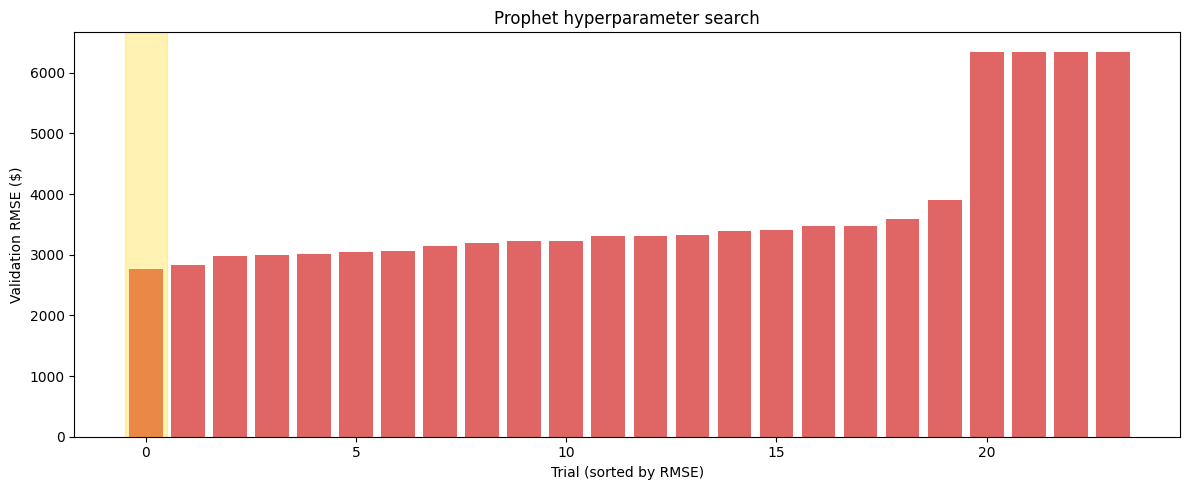

In [26]:
PROPHET_BEST_CFG = dict(
    seasonality_mode=best_row['seasonality_mode'],
    changepoint_prior_scale=float(best_row['changepoint_prior_scale']),
    holidays_prior_scale=float(best_row['holidays_prior_scale']),
    yearly_order=int(best_row['yearly_order']),
    min_history=int(best_row['min_history']),
)
print("Best Prophet config (on fixed sample):", PROPHET_BEST_CFG)
print(f"Sample RMSE: {best_row['rmse']:.2f}  |  Sample WMAE: {best_row['wmae']:.2f}")

fig, ax = plt.subplots(figsize=(12, 5))
sorted_log = prophet_search_df.sort_values('rmse').reset_index(drop=True)
x = np.arange(len(sorted_log))
ax.bar(x, sorted_log['rmse'], color='#e06666')
ax.axvspan(-0.5, 0.5, color='gold', alpha=0.3)
ax.set_xlabel('Trial (sorted by RMSE)')
ax.set_ylabel('Validation RMSE ($)')
ax.set_title('Prophet hyperparameter search')
plt.tight_layout()
plt.show()

## 13. Run — Prophet, full population

The winning configuration is now fit across **every** eligible Store/Dept
series (not a subset).

In [27]:
ALL_PROPHET_KEYS = list(series_val.keys())
print(f"Full population: {len(ALL_PROPHET_KEYS)} series")

with mlflow.start_run(run_name="Prophet_Final") as prophet_final_run:
    full_prophet_metrics, full_prophet_pred_map, prophet_fallback_keys = run_prophet_trial(
        PROPHET_BEST_CFG, ALL_PROPHET_KEYS, n_jobs=-1
    )
    mlflow.log_params(PROPHET_BEST_CFG)
    mlflow.log_param("sample_size", len(SEARCH_SAMPLE))
    mlflow.log_param("n_series_full", len(ALL_PROPHET_KEYS))
    mlflow.log_metrics(full_prophet_metrics)
    mlflow.set_tag("stage", "full_population")
    mlflow.set_tag("model_type", "Prophet")

print(f"Full population val RMSE: {full_prophet_metrics['rmse']:.2f}")
print(f"Full population val WMAE: {full_prophet_metrics['wmae']:.2f}")
print(f"Fitted series: {full_prophet_metrics['n_fit']}  |  Fallback series: {full_prophet_metrics['n_fallback']}")

Full population: 3093 series
🏃 View run Prophet_Final at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/53c130c75a154439a3e57acb57666112
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
Full population val RMSE: 2854.49
Full population val WMAE: 1388.49
Fitted series: 2851  |  Fallback series: 242


In [28]:
# Prophet validation predictions, aligned to Store/Dept/Date -- same schema as the XGBoost alignment above.
prophet_val_rows = []
for key in ALL_PROPHET_KEYS:
    store, dept = key
    va = series_val[key]
    preds = full_prophet_pred_map[key] if key in full_prophet_pred_map else seasonal_naive_forecast(key, len(va))
    for ds, y_val_i, pred_i in zip(va['ds'], va['y'], preds):
        prophet_val_rows.append({'Store': store, 'Dept': dept, 'Date': ds, 'y_true': y_val_i, 'prophet_pred': pred_i})

prophet_val_aligned = pd.DataFrame(prophet_val_rows)
print(prophet_val_aligned.shape)
prophet_val_aligned.head()

(35563, 5)


,Store,Dept,Date,y_true,prophet_pred
0,1,1,2012-08-10,16119.92,15654.354545
1,1,1,2012-08-17,17330.70,15400.647663
2,1,1,2012-08-24,16286.40,14593.922463
3,1,1,2012-08-31,16680.24,16117.215822
4,1,1,2012-09-07,18322.37,18107.718928


## 14. Ensembling

Both branches' validation predictions are merged on `(Store, Dept, Date)`.
Two combination strategies are compared on the shared validation window:

- **Weighted blend**: `alpha * xgb_pred + (1 - alpha) * prophet_pred`,
  scanning `alpha` on a fine grid and keeping whichever minimizes RMSE.
- **Stacked meta-model**: a non-negative `Ridge` regression on
  `[xgb_pred, prophet_pred] -> y`, cross-fit with `KFold` so every row's
  meta-prediction comes from a model that never saw that row during
  training — an honest out-of-fold estimate rather than an in-sample one.

Whichever validates better by RMSE (the primary target metric for this
notebook) is used for the final test-set submission; WMAE is reported
alongside for both, since it's the competition's actual metric.

In [29]:
ensemble_val = xgb_val_aligned.merge(
    prophet_val_aligned, on=['Store', 'Dept', 'Date'], suffixes=('_xgb', '_prophet')
)
assert abs(len(ensemble_val) - len(xgb_val_aligned)) <= 5, 'branches did not align on the shared validation window'
np.testing.assert_allclose(
    ensemble_val['y_true_xgb'].to_numpy(), ensemble_val['y_true_prophet'].to_numpy(), rtol=1e-6
)

y_true_ens = ensemble_val['y_true_xgb'].to_numpy()
xgb_pred_ens = ensemble_val['xgb_pred'].to_numpy()
prophet_pred_ens = ensemble_val['prophet_pred'].to_numpy()

holiday_lookup = train_sorted.set_index(['Store', 'Dept', 'Date'])['IsHoliday']
is_holiday_ens = ensemble_val.set_index(['Store', 'Dept', 'Date']).index.map(holiday_lookup).to_numpy()

print(f"Aligned validation rows: {len(ensemble_val)}")
print(f"XGBoost only     -> {report_metrics(y_true_ens, xgb_pred_ens, is_holiday_ens)}")
print(f"Prophet only     -> {report_metrics(y_true_ens, prophet_pred_ens, is_holiday_ens)}")

Aligned validation rows: 35563
XGBoost only     -> {'rmse': 4518.309490103244, 'wmae': 2051.128556663656}
Prophet only     -> {'rmse': 2854.486303370472, 'wmae': 1388.4915127796764}


In [30]:
# --- Weighted blend ---
alphas = np.linspace(0.0, 1.0, 41)
blend_scan = []
for a in alphas:
    blend = a * xgb_pred_ens + (1 - a) * prophet_pred_ens
    blend_scan.append({'alpha': a, 'rmse': root_mean_squared_error(y_true_ens, blend),
                        'wmae': weighted_mae(y_true_ens, blend, is_holiday_ens)})
blend_scan_df = pd.DataFrame(blend_scan).sort_values('rmse').reset_index(drop=True)
BEST_ALPHA = float(blend_scan_df.iloc[0]['alpha'])
blend_pred_ens = BEST_ALPHA * xgb_pred_ens + (1 - BEST_ALPHA) * prophet_pred_ens
blend_metrics = report_metrics(y_true_ens, blend_pred_ens, is_holiday_ens)

print(f"Best blend alpha (weight on XGBoost): {BEST_ALPHA:.2f}")
print(f"Weighted blend   -> {blend_metrics}")

# --- Stacked meta-model, cross-fit for an honest out-of-fold score ---
X_meta = np.column_stack([xgb_pred_ens, prophet_pred_ens])
kf = KFold(n_splits=5, shuffle=False)
meta_oof_pred = np.zeros_like(y_true_ens, dtype=float)
for tr_idx, te_idx in kf.split(X_meta):
    fold_meta = Ridge(alpha=1.0, positive=True)
    fold_meta.fit(X_meta[tr_idx], y_true_ens[tr_idx])
    meta_oof_pred[te_idx] = fold_meta.predict(X_meta[te_idx])
stacked_metrics = report_metrics(y_true_ens, meta_oof_pred, is_holiday_ens)
print(f"Stacked (OOF)    -> {stacked_metrics}")

# Meta-model fit on the full validation window, to be applied to the real test set later.
FINAL_META_MODEL = Ridge(alpha=1.0, positive=True)
FINAL_META_MODEL.fit(X_meta, y_true_ens)
print(f"\nFinal meta-model coefficients (xgb, prophet): {FINAL_META_MODEL.coef_}, intercept: {FINAL_META_MODEL.intercept_:.2f}")

Best blend alpha (weight on XGBoost): 0.18
Weighted blend   -> {'rmse': 2751.5025774612245, 'wmae': 1332.2349445985876}
Stacked (OOF)    -> {'rmse': 2745.4031697398605, 'wmae': 1356.921450484037}

Final meta-model coefficients (xgb, prophet): [0.16997746 0.81824972], intercept: 166.99


In [31]:
ensemble_candidates = {
    'xgb_only': (report_metrics(y_true_ens, xgb_pred_ens, is_holiday_ens), xgb_pred_ens),
    'prophet_only': (report_metrics(y_true_ens, prophet_pred_ens, is_holiday_ens), prophet_pred_ens),
    'weighted_blend': (blend_metrics, blend_pred_ens),
    'stacked_meta': (stacked_metrics, meta_oof_pred),
}
ENSEMBLE_WINNER = min(ensemble_candidates, key=lambda k: ensemble_candidates[k][0]['rmse'])
winner_metrics = ensemble_candidates[ENSEMBLE_WINNER][0]

with mlflow.start_run(run_name="Ensemble_Comparison"):
    for name, (metrics, _) in ensemble_candidates.items():
        mlflow.log_metric(f"{name}_rmse", metrics['rmse'])
        mlflow.log_metric(f"{name}_wmae", metrics['wmae'])
    mlflow.log_param("winner", ENSEMBLE_WINNER)
    mlflow.log_param("best_blend_alpha", BEST_ALPHA)
    mlflow.set_tag("stage", "ensembling")

print("Validation comparison across the shared validation window:")
for name, (metrics, _) in sorted(ensemble_candidates.items(), key=lambda kv: kv[1][0]['rmse']):
    print(f"  {name:16s} rmse={metrics['rmse']:9.2f}  wmae={metrics['wmae']:9.2f}")
print(f"\nWinner (lowest validation RMSE): {ENSEMBLE_WINNER}")
print(f"  RMSE={winner_metrics['rmse']:.2f}  WMAE={winner_metrics['wmae']:.2f}")

🏃 View run Ensemble_Comparison at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4/runs/86800d854e0d494588dfb7a8048ecf6f
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/4
Validation comparison across the shared validation window:
  stacked_meta     rmse=  2745.40  wmae=  1356.92
  weighted_blend   rmse=  2751.50  wmae=  1332.23
  prophet_only     rmse=  2854.49  wmae=  1388.49
  xgb_only         rmse=  4518.31  wmae=  2051.13

Winner (lowest validation RMSE): stacked_meta
  RMSE=2745.40  WMAE=1356.92


## 15. Refit on full history and generate test-set predictions

Both branches are refit on all labelled data (the pre-cutoff and validation
windows combined), then the same combination method chosen above is applied
to produce the final submission.

In [32]:
# XGBoost test predictions were already produced by the production pipeline in section 10.
xgb_test_aligned = test_raw[['Store', 'Dept', 'Date']].copy()
xgb_test_aligned['xgb_pred'] = xgb_test_preds

In [33]:
# Prophet: refit every eligible series on its FULL labelled history, forecast the actual test dates.
full_prophet_series = {}
for (store, dept), g in train_sorted.groupby(['Store', 'Dept'], sort=False):
    g = g.sort_values('Date')
    full_prophet_series[(store, dept)] = g.rename(
        columns={'Date': 'ds', 'Weekly_Sales': 'y'}
    )[['ds', 'y']].reset_index(drop=True)

test_series_groups = {k: g.sort_values('Date') for k, g in test_raw.groupby(['Store', 'Dept'], sort=False)}

refit_keys = [k for k in test_series_groups
              if k in full_prophet_series and len(full_prophet_series[k]) >= PROPHET_BEST_CFG['min_history']]
print(f"Series refit on full history: {len(refit_keys)} / {len(test_series_groups)} test series")

refit_results = Parallel(n_jobs=-1)(
    delayed(fit_one_series)(k, full_prophet_series[k], test_series_groups[k]['Date'].to_numpy(), PROPHET_BEST_CFG)
    for k in refit_keys
)
refit_pred_map = {r['key']: r['val_pred'] for r in refit_results}

Series refit on full history: 2879 / 3169 test series


In [34]:
def naive_test_forecast(key, horizon):
    hist = full_prophet_series[key]['y'].to_numpy() if key in full_prophet_series else np.array([])
    if len(hist) >= 52:
        return np.full(horizon, hist[-52])
    if len(hist) > 0:
        return np.full(horizon, hist[-1])
    return np.full(horizon, float(np.median(y_full)))


prophet_test_rows = []
for key, g in test_series_groups.items():
    preds = refit_pred_map[key] if key in refit_pred_map else naive_test_forecast(key, len(g))
    prophet_test_rows.append(pd.DataFrame({
        'Store': key[0], 'Dept': key[1], 'Date': g['Date'].to_numpy(), 'prophet_pred': preds
    }))
prophet_test_aligned = pd.concat(prophet_test_rows, ignore_index=True)
assert prophet_test_aligned.shape[0] == test_raw.shape[0]
assert prophet_test_aligned['prophet_pred'].isna().sum() == 0
print(f"Prophet test predictions: {prophet_test_aligned.shape}")

Prophet test predictions: (115064, 4)


In [35]:
test_blend = test_raw[['Store', 'Dept', 'Date']] \
    .merge(xgb_test_aligned, on=['Store', 'Dept', 'Date'], how='left') \
    .merge(prophet_test_aligned, on=['Store', 'Dept', 'Date'], how='left')

assert test_blend.shape[0] == test_raw.shape[0]
assert test_blend[['xgb_pred', 'prophet_pred']].isnull().sum().sum() == 0, 'unmatched rows after test-set alignment'

if ENSEMBLE_WINNER == 'xgb_only':
    test_blend['final_pred'] = test_blend['xgb_pred']
elif ENSEMBLE_WINNER == 'prophet_only':
    test_blend['final_pred'] = test_blend['prophet_pred']
elif ENSEMBLE_WINNER == 'weighted_blend':
    test_blend['final_pred'] = BEST_ALPHA * test_blend['xgb_pred'] + (1 - BEST_ALPHA) * test_blend['prophet_pred']
else:  # stacked_meta
    X_meta_test = test_blend[['xgb_pred', 'prophet_pred']].to_numpy()
    test_blend['final_pred'] = FINAL_META_MODEL.predict(X_meta_test)

submission = pd.DataFrame({
    'Id': (test_blend['Store'].astype(str) + '_' + test_blend['Dept'].astype(str) + '_'
           + test_blend['Date'].dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': test_blend['final_pred'],
})
assert submission.shape[0] == test_raw.shape[0]
assert submission['Weekly_Sales'].isna().sum() == 0

submission_path = f'{MODELS_DIR}/ensemble_submission.csv'
submission.to_csv(submission_path, index=False)
print(f"Combination method used for the submission: {ENSEMBLE_WINNER}")
print(f"Saved: {submission_path}")
submission.head()

Combination method used for the submission: stacked_meta
Saved: /content/drive/MyDrive/walmart/models/ensemble_submission.csv


,Id,Weekly_Sales
0,1_1_2012-11-02,35946.257780
1,1_1_2012-11-09,23976.499204
2,1_1_2012-11-16,18594.016487
3,1_1_2012-11-23,20068.813397
4,1_1_2012-11-30,25639.947842


## 16. Summary

| Stage | Result |
|---|---|
| XGBoost hold-out validation | see `xgb_val_metrics` above |
| Prophet full-population validation | see `full_prophet_metrics` above |
| Ensemble winner | `ENSEMBLE_WINNER`, chosen by validation RMSE |
| Ensemble validation score | `winner_metrics` |

Both branches, and the ensembling step that combines them, are evaluated on
the identical held-out window defined once in section 4 — so the RMSE/WMAE
lift attributed to ensembling reflects a genuine improvement over either
branch alone rather than a difference in what each branch was scored
against. WMAE is reported throughout as the competition's actual metric but
was never used as a training objective — every model was fit on plain,
unweighted targets, with the 5x holiday weighting applied only when scoring
predictions.

In [36]:
print("XGBoost hold-out validation:", xgb_val_metrics)
print("Prophet full-population validation:", full_prophet_metrics)
print(f"Ensemble winner: {ENSEMBLE_WINNER}")
print("Ensemble validation score:", winner_metrics)

XGBoost hold-out validation: {'rmse': 4518.309490103244, 'wmae': 2051.128556663656}
Prophet full-population validation: {'rmse': 2854.486303370472, 'wmae': 1388.4915127796764, 'n_fit': 2851, 'n_fallback': 242, 'elapsed_sec': 424.8655700683594}
Ensemble winner: stacked_meta
Ensemble validation score: {'rmse': 2745.4031697398605, 'wmae': 1356.921450484037}
